In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import font_manager, markers, rc
font_path = "../resData/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

In [3]:
# 그래프 스타일 설정
plt.style.use('ggplot')
'''
그래프에 음수기호를 유니코드가 아닌 ASCII 코드로 출력되도록 하는 설정.
이 설정이 없으면 - 기호를 인식하지 못해 깨짐현상이 발생된다.
'''
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 엑셀파일을 데이터프레임으로 변환. header옵션이 없으므로 첫행은 타이틀로 인식
df = pd.read_excel('../resData/남북한_발전_전력량.xlsx', engine='openpyxl')
# 엑셀의 인덱스 5~8까지, 즉 북한의 합계~원자력 행을 선택해서 변수에 저장
df = df.loc[5:9]
df # 노트북에서는 변수명만 있으면 즉시 출력됨

,전력량 (억㎾h),발전 전력별,1990,1991,1992,1993,1994,1995,1996,1997,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
5,북한,합계,277,263,247,221,231,230,213,193,...,236,255,235,237,211,215,221,216,190,239
6,NaN,수력,156,150,142,133,138,142,125,107,...,133,141,125,134,132,135,139,130,100,128
7,NaN,화력,121,113,105,88,93,88,88,86,...,103,114,110,103,79,80,82,86,90,111
8,NaN,원자력,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [5]:
# 전력량 컬럼을 삭제한 후 원본 데이터프레임에 적용
df.drop('전력량 (억㎾h)', axis='columns', inplace=True)
df

,발전 전력별,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
5,합계,277,263,247,221,231,230,213,193,170,...,236,255,235,237,211,215,221,216,190,239
6,수력,156,150,142,133,138,142,125,107,102,...,133,141,125,134,132,135,139,130,100,128
7,화력,121,113,105,88,93,88,88,86,68,...,103,114,110,103,79,80,82,86,90,111
8,원자력,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [6]:
# 첫번째 컬럼을 인덱스로 지정한 후 원본 데이터프레임에 적용
df.set_index('발전 전력별', inplace=True)
df

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
발전 전력별,,,,,,,,,,,,,,,,,,,,,
합계,277,263,247,221,231,230,213,193,170,186,...,236,255,235,237,211,215,221,216,190,239
수력,156,150,142,133,138,142,125,107,102,103,...,133,141,125,134,132,135,139,130,100,128
화력,121,113,105,88,93,88,88,86,68,83,...,103,114,110,103,79,80,82,86,90,111
원자력,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-


In [7]:
# 데이터프레임을 클래스 속성 T를 사용해서 전치(행과 열을 교환)
df = df.T
df

발전 전력별,합계,수력,화력,원자력
1990,277,156,121,-
1991,263,150,113,-
1992,247,142,105,-
1993,221,133,88,-
1994,231,138,93,-
1995,230,142,88,-
1996,213,125,88,-
1997,193,107,86,-
1998,170,102,68,-
1999,186,103,83,-


In [8]:
# 증감률(변동률) 계산을 위해 '합계'를 '총발전량'으로 이름 변경
df = df.rename(columns={'합계':'총발전량'})
df

발전 전력별,총발전량,수력,화력,원자력
1990,277,156,121,-
1991,263,150,113,-
1992,247,142,105,-
1993,221,133,88,-
1994,231,138,93,-
1995,230,142,88,-
1996,213,125,88,-
1997,193,107,86,-
1998,170,102,68,-
1999,186,103,83,-


In [9]:
# 총발전량 컬럼을 데이터를 1행씩 뒤로 이동(shift)시킨 후 새로운 컬럼으로 복사한다.
df['총발전량 - 1년'] = df['총발전량'].shift(1)
df

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년
1990,277,156,121,-,None
1991,263,150,113,-,277
1992,247,142,105,-,263
1993,221,133,88,-,247
1994,231,138,93,-,221
1995,230,142,88,-,231
1996,213,125,88,-,230
1997,193,107,86,-,213
1998,170,102,68,-,193
1999,186,103,83,-,170


In [10]:
# 증감률을 계산하여 새로운 컬럼을 생성한다.
df['증감률'] = ((df['총발전량']/df['총발전량 - 1년']) - 1) * 100
df

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년,증감률
1990,277,156,121,-,None,NaN
1991,263,150,113,-,277,-5.054152
1992,247,142,105,-,263,-6.08365
1993,221,133,88,-,247,-10.526316
1994,231,138,93,-,221,4.524887
1995,230,142,88,-,231,-0.4329
1996,213,125,88,-,230,-7.391304
1997,193,107,86,-,213,-9.389671
1998,170,102,68,-,193,-11.917098
1999,186,103,83,-,170,9.411765


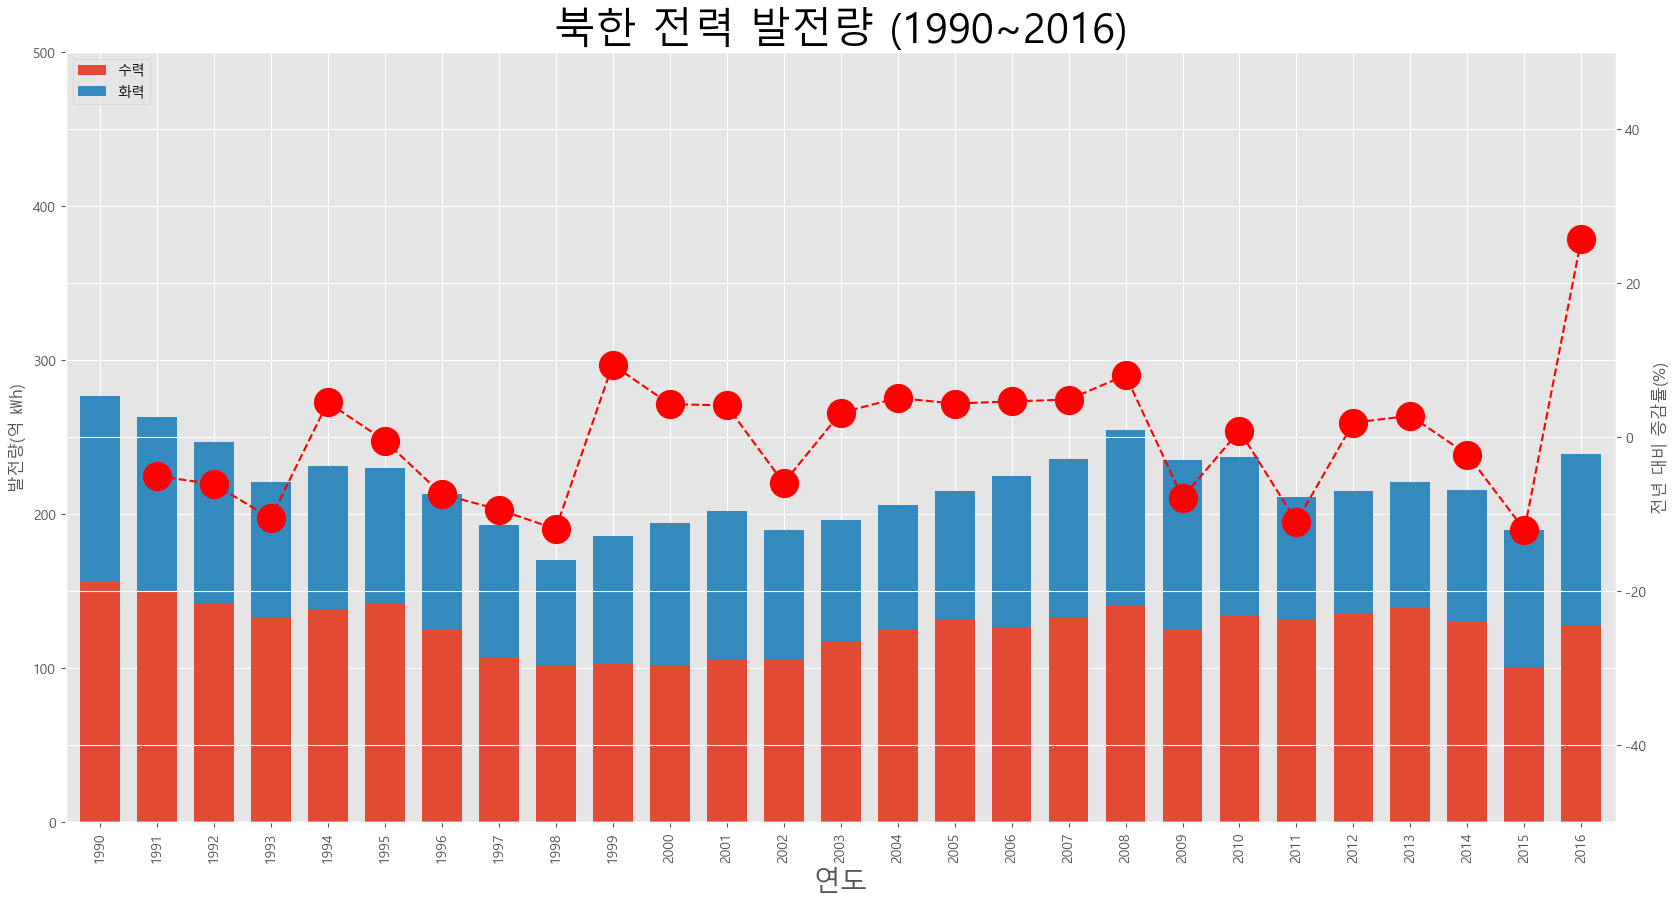

In [11]:
'''
수력, 화력 데이터를 이용해서 2개의 축을 가진 그래프를 생성한다.
수직형 막대(bar) 그래프가 겹쳐지지(stacked) 않도록 설정한다.
'''
axe1 = df[['수력','화력']].plot(kind='bar', figsize=(20,10), width=0.7, 
                            stacked=True)
# twin 함수로 Axe 객체의 복사본 생성
axe2 = axe1.twinx()
'''
생성된 복사본은 꺽은선 그래프(kind 옵션이 없을때 디폴트값)를 생성한다. 증감률 컬럼을 사용하고, 
ls옵션은 선 스타일을 점선으로 설정한다.
'''
axe2.plot(df.index, df.증감률, ls='--', marker='o', markersize=20,
          color='red', label='전년대비 증감률(%)')
# y축의 범위 설정
axe1.set_ylim(0, 500)
axe2.set_ylim(-50, 50)
# 라벨 설정
axe1.set_xlabel('연도', size=20)
axe1.set_ylabel('발전량(억 ㎾h)')
axe2.set_ylabel('전년 대비 증감률(%)')
# 타이틀, 범례 표시
plt.title('북한 전력 발전량 (1990~2016)', size=30)  
axe1.legend(loc='upper left')